survey_results_public.csv (49,191 rows)  ← DATA MENTAH
        ↓
STEP 1  : Load Dataset
        ↓
STEP 2  : Filter & Mapping DevType → 18 Label Karir
        ↓
STEP 3  : Cleaning Fitur Skill (all_skills, tools, databases)
        ↓
STEP 4  : Cleaning Fitur Numerik & Kategorikal
        ↓
STEP 5  : Drop Duplikat & Baris Tanpa Skill
        ↓
STEP 6  : Susun Kolom Final
        ↓
STEP 7  : Validasi & Distribusi Label
        ↓
STEP 8  : Dataset Bersih (Pre-SMOTE) → disimpan di MEMORI (df_clean)
        ↓
STEP 9  : Feature Engineering (Numeric only - untuk SMOTE)
        ↓
STEP 10 : Train-Test Split (80/20, Stratified)
        ↓
STEP 11 : Feature Scaling (untuk SMOTE)
        ↓
STEP 12 : SMOTE (hanya pada training set)
        ↓
STEP 13 : Gabung Dataset Balanced (Post-SMOTE) → disimpan di MEMORI (df_balanced)
        ↓
STEP 14 : Visualisasi Distribusi Dataset (Sebelum vs Sesudah SMOTE)
        ↓
STEP 15 : Data Injection Keyword Karir
        ↓
STEP 16 : Validasi Akhir + Visualisasi → SIMPAN SATU FILE FINAL
                                          dataset_so_smote_balanced_injected.csv

CATATAN: Hanya SATU file CSV final yang dihasilkan, yaitu dataset akhir
yang sudah siap digunakan pada tahap pemodelan. Dataset antara
(pre-SMOTE & post-SMOTE) cukup disimpan sebagai DataFrame di memori.

## Setup Library & Konfigurasi

Pada tahap awal, dilakukan import seluruh library yang dibutuhkan untuk proses data wrangling:

- **`pandas` & `numpy`** — manipulasi dan komputasi data tabular
- **`sklearn`** — `LabelEncoder`, `StandardScaler`, dan `train_test_split` untuk persiapan data modeling
- **`imblearn`** — `SMOTE` untuk oversampling kelas minoritas
- **`matplotlib`** — visualisasi distribusi data

Selain itu, didefinisikan path file input/output serta kolom-kolom yang akan diambil dari dataset mentah Stack Overflow Survey untuk efisiensi memori.

In [1]:
import pandas as pd
import numpy as np
import warnings
import os
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
PATH_SO    = "survey_results_public.csv"                      # input: data mentah survei
PATH_FINAL = "dataset_so_smote_balanced_injected.csv"        # output: SATU file dataset akhir

SO_COLS = [
    'DevType',
    'LanguageHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'DevEnvsHaveWorkedWith',
    'YearsCode',
    'EdLevel',
]

print(f"Input  : {PATH_SO}")
print(f"Output : {PATH_FINAL}  (hanya 1 file)")
print("Dataset antara (pre-SMOTE & post-SMOTE) disimpan sebagai DataFrame di memori, tidak ditulis ke disk.")

Input  : survey_results_public.csv
Output : dataset_so_smote_balanced_injected.csv  (hanya 1 file)
Dataset antara (pre-SMOTE & post-SMOTE) disimpan sebagai DataFrame di memori, tidak ditulis ke disk.


In [3]:
SO_DEVTYPE_TO_CAREER = {
    "Developer, front-end": "Frontend Developer",
    "Developer, back-end": "Backend Developer",
    "Developer, full-stack": "Full Stack Developer",
    "Developer, mobile": "Mobile App Developer",
    "Developer, game or graphics": "Game Developer",
    "Developer, desktop or enterprise applications": "Backend Developer",
    "Developer, embedded applications or devices": "Backend Developer",
    "Architect, software or solutions": "Backend Developer",
    "Data or business analyst": "Data Analyst",
    "Data engineer": "Data Engineer",
    "Data scientist": "Data Scientist",
    "AI/ML engineer": "Machine Learning Engineer",
    "Developer, AI apps or physical AI": "Machine Learning Engineer",
    "Applied scientist": "Machine Learning Engineer",
    "Cloud infrastructure engineer": "Cloud Engineer",
    "DevOps engineer or professional": "DevOps Engineer",
    "System administrator": "System Administrator",
    "Cybersecurity or InfoSec professional": "Cybersecurity Analyst",
    "Database administrator or engineer": "Database Administrator (DBA)",
    "UX, Research Ops or UI design professional": "UX Designer",
    "Developer, QA or test": "QA Engineer",
    "Support engineer or analyst": "IT Support Specialist",
    "Product manager": "Product Manager (Teknologi)",
}

EDLEVEL_MAP = {
    "Primary/elementary school": 0,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
    "Some college/university study without earning a degree": 2,
    "Associate degree (A.A., A.S., etc.)": 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
    "Other (please specify):": 2,
}

print(f"✅ {len(set(SO_DEVTYPE_TO_CAREER.values()))} label karir siap")

✅ 18 label karir siap


In [4]:
def split_semicolon(val):
    if not isinstance(val, str) or pd.isna(val):
        return []
    return [v.strip() for v in val.split(';') if v.strip()]

def normalize_skill(skill):
    return skill.strip().lower()

def get_primary_devtype(devtype_str):
    types = split_semicolon(devtype_str)
    for t in types:
        if t in SO_DEVTYPE_TO_CAREER:
            return t
    return None

def merge_all_skills(row, skill_cols):
    combined = set()
    for col in skill_cols:
        val = row.get(col, '')
        for skill in split_semicolon(str(val) if pd.notna(val) else ''):
            normalized = normalize_skill(skill)
            if normalized:
                combined.add(normalized)
    return ';'.join(sorted(combined))

def clean_years_code(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if 'less than 1' in val_str.lower():
        return 0.0
    if 'more than 50' in val_str.lower():
        return 50.0
    try:
        return float(val_str)
    except ValueError:
        return np.nan

print("✅ Helper functions siap")

✅ Helper functions siap


## STEP 1 — Load Dataset

Dataset yang digunakan adalah **Stack Overflow Developer Survey** (`survey_results_public.csv`), sebuah survei tahunan yang diikuti oleh puluhan ribu pengembang di seluruh dunia.

Dari 80+ kolom yang tersedia, hanya **8 kolom relevan** yang dimuat untuk efisiensi:

| Kolom | Keterangan |
|---|---|
| `DevType` | Tipe pekerjaan / peran developer |
| `LanguageHaveWorkedWith` | Bahasa pemrograman yang pernah digunakan |
| `WebframeHaveWorkedWith` | Framework web yang pernah digunakan |
| `DatabaseHaveWorkedWith` | Database yang pernah digunakan |
| `PlatformHaveWorkedWith` | Platform / cloud yang pernah digunakan |
| `DevEnvsHaveWorkedWith` | Tools / IDE yang pernah digunakan |
| `YearsCode` | Lama pengalaman coding |
| `EdLevel` | Tingkat pendidikan |

Missing values yang signifikan (terutama di kolom skill) akan ditangani di langkah-langkah berikutnya.

In [5]:
print("=" * 65)
print("STEP 1 : LOADING DATASET")
print("=" * 65)

df_so = pd.read_csv(PATH_SO, usecols=SO_COLS, low_memory=False)

print(f"\n  Rows loaded    : {len(df_so):,}")
print(f"  Columns        : {list(df_so.columns)}")
print(f"\n  Missing values per kolom:")
for col in df_so.columns:
    n = df_so[col].isna().sum()
    print(f"    {col:<35}: {n:>6,} ({n/len(df_so)*100:.1f}%)")

STEP 1 : LOADING DATASET



  Rows loaded    : 49,191
  Columns        : ['EdLevel', 'YearsCode', 'DevType', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'DevEnvsHaveWorkedWith']

  Missing values per kolom:
    EdLevel                            :  1,042 (2.1%)
    YearsCode                          :  6,149 (12.5%)
    DevType                            :  5,511 (11.2%)
    LanguageHaveWorkedWith             : 17,520 (35.6%)
    DatabaseHaveWorkedWith             : 23,641 (48.1%)
    PlatformHaveWorkedWith             : 24,933 (50.7%)
    WebframeHaveWorkedWith             : 26,199 (53.3%)
    DevEnvsHaveWorkedWith              : 23,172 (47.1%)


## STEP 2 — Filter & Mapping DevType → Label Karir

Kolom `DevType` berisi nilai multi-pilihan (dipisahkan `;`) karena satu responden dapat memiliki lebih dari satu tipe pekerjaan. Pada langkah ini dilakukan tiga sub-proses:

1. **Drop baris tanpa `DevType`** — responden yang tidak mengisi tipe pekerjaan tidak dapat dikategorikan dan dihapus.
2. **Ambil DevType primer** — dari daftar multi-value, diambil satu DevType pertama yang cocok dengan peta karir yang telah didefinisikan.
3. **Mapping ke 18 label karir IT** — DevType mentah (misalnya `"Developer, front-end"`) dipetakan ke label standar (misalnya `"Frontend Developer"`).

DevType yang tidak relevan (misalnya `"Academic researcher"`) tidak memiliki mapping dan otomatis terdrop bersama baris yang tidak cocok.

In [6]:
print("\n" + "=" * 65)
print("STEP 2 : FILTER & MAPPING DEVTYPE → LABEL KARIR")
print("=" * 65)

before = len(df_so)
df_so = df_so.dropna(subset=['DevType']).copy()
print(f"\n  [2.1] Drop baris tanpa DevType   : {before:,} → {len(df_so):,} rows")

df_so['DevType_primary'] = df_so['DevType'].apply(get_primary_devtype)

before = len(df_so)
df_so = df_so.dropna(subset=['DevType_primary']).copy()
print(f"  [2.2] Drop DevType tidak relevan : {before:,} → {len(df_so):,} rows")

df_so['career_label'] = df_so['DevType_primary'].map(SO_DEVTYPE_TO_CAREER)
before = len(df_so)
df_so = df_so.dropna(subset=['career_label']).copy()
print(f"  [2.3] Drop unmapped career label : {before:,} → {len(df_so):,} rows")

print(f"\n  Distribusi awal label karir:")
dist = df_so['career_label'].value_counts()
for career, count in dist.items():
    bar = "█" * min(count // 30, 35)
    print(f"    {career:<42}: {count:>5}  {bar}")


STEP 2 : FILTER & MAPPING DEVTYPE → LABEL KARIR

  [2.1] Drop baris tanpa DevType   : 49,191 → 43,680 rows
  [2.2] Drop DevType tidak relevan : 43,680 → 34,835 rows
  [2.3] Drop unmapped career label : 34,835 → 34,835 rows

  Distribusi awal label karir:
    Full Stack Developer                      : 12351  ███████████████████████████████████
    Backend Developer                         : 12330  ███████████████████████████████████
    Frontend Developer                        :  1974  ███████████████████████████████████
    Mobile App Developer                      :  1391  ███████████████████████████████████
    Machine Learning Engineer                 :  1210  ███████████████████████████████████
    DevOps Engineer                           :  1053  ███████████████████████████████████
    Data Engineer                             :   770  █████████████████████████
    Data Scientist                            :   574  ███████████████████
    System Administrator                  

## STEP 3 — Cleaning Fitur Skill

Tiga kelompok fitur skill digabungkan dari kolom-kolom mentah yang berbeda, kemudian dinormalisasi:

- **`all_skills`** — gabungan dari `LanguageHaveWorkedWith`, `WebframeHaveWorkedWith`, dan `PlatformHaveWorkedWith`. Setiap item dinormalisasi ke huruf kecil, diurutkan alfabetis, dan dipisahkan dengan `;`.
- **`tools`** — dibuat dari `DevEnvsHaveWorkedWith`, merepresentasikan IDE dan development tools yang digunakan.
- **`databases`** — dibuat dari `DatabaseHaveWorkedWith`, merepresentasikan teknologi basis data yang dikuasai.

Proses normalisasi memastikan tidak ada duplikasi skill akibat perbedaan kapitalisasi atau spasi ekstra. Baris yang tidak memiliki skill sama sekali akan ditangani pada STEP 5.

In [7]:
print("\n" + "=" * 65)
print("STEP 3 : CLEANING FITUR SKILL")
print("=" * 65)

SKILL_COLS = [
    'LanguageHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'PlatformHaveWorkedWith',
]

df_so['all_skills'] = df_so.apply(
    lambda row: merge_all_skills(row, SKILL_COLS), axis=1
)
print(f"\n  [3.1] all_skills dibuat dari   : {SKILL_COLS}")

df_so['tools'] = df_so['DevEnvsHaveWorkedWith'].apply(
    lambda x: ';'.join(sorted([normalize_skill(s) for s in split_semicolon(str(x))
                                if s])) if pd.notna(x) else ''
)
print(f"  [3.2] tools dibuat dari        : DevEnvsHaveWorkedWith")

df_so['databases'] = df_so['DatabaseHaveWorkedWith'].apply(
    lambda x: ';'.join(sorted([normalize_skill(s) for s in split_semicolon(str(x))
                                if s])) if pd.notna(x) else ''
)
print(f"  [3.3] databases dibuat dari    : DatabaseHaveWorkedWith")

total = len(df_so)
for col in ['all_skills', 'tools', 'databases']:
    filled = (df_so[col] != '').sum()
    print(f"\n  {col:<15}: {filled:,}/{total:,} terisi ({filled/total*100:.1f}%)")


STEP 3 : CLEANING FITUR SKILL



  [3.1] all_skills dibuat dari   : ['LanguageHaveWorkedWith', 'WebframeHaveWorkedWith', 'PlatformHaveWorkedWith']
  [3.2] tools dibuat dari        : DevEnvsHaveWorkedWith
  [3.3] databases dibuat dari    : DatabaseHaveWorkedWith

  all_skills     : 25,804/34,835 terisi (74.1%)

  tools          : 21,181/34,835 terisi (60.8%)

  databases      : 21,426/34,835 terisi (61.5%)


## STEP 4 — Cleaning Fitur Numerik & Kategorikal

Dua fitur perlu dibersihkan dan dikonversi ke format numerik sebelum dapat digunakan dalam pemodelan:

**`YearsCode` → `years_code` (float)**
- Nilai `"Less than 1 year"` dikonversi ke `0.0`
- Nilai `"More than 50 years"` dikonversi ke `50.0`
- Missing values diimputasi dengan **nilai median** agar tidak terpengaruh oleh outlier

**`EdLevel` → `education_level` (ordinal 0–6)**
- Tingkat pendidikan dikonversi ke skala ordinal menggunakan mapping manual:

| Nilai Asli | Kode |
|---|---|
| SD / Primary school | 0 |
| SMA / Secondary school | 1 |
| Kuliah tanpa gelar | 2 |
| D3 / Associate degree | 3 |
| S1 / Bachelor's degree | 4 |
| S2 / Master's degree | 5 |
| S3 / Professional degree | 6 |

- Missing values diimputasi dengan **nilai median** dari distribusi tingkat pendidikan.

In [8]:
print("\n" + "=" * 65)
print("STEP 4 : CLEANING FITUR NUMERIK & KATEGORIKAL")
print("=" * 65)

df_so['years_code'] = df_so['YearsCode'].apply(clean_years_code)
median_years = df_so['years_code'].median()
before_null = df_so['years_code'].isna().sum()
df_so['years_code'] = df_so['years_code'].fillna(median_years)

print(f"\n  [4.1] YearsCode  : {before_null} NaN diimputasi dengan median ({median_years:.1f})")
print(f"        Range      : {df_so['years_code'].min():.0f} – {df_so['years_code'].max():.0f} tahun")

df_so['education_level'] = df_so['EdLevel'].map(EDLEVEL_MAP)
before_null = df_so['education_level'].isna().sum()
median_edu = df_so['education_level'].median()
df_so['education_level'] = df_so['education_level'].fillna(median_edu)

print(f"  [4.2] EdLevel    : {before_null} NaN diimputasi dengan median ({median_edu:.0f})")
print(f"        Encoding   : 0=SD, 1=SMA, 2=Tanpa gelar, 3=D3, 4=S1, 5=S2, 6=S3")


STEP 4 : CLEANING FITUR NUMERIK & KATEGORIKAL



  [4.1] YearsCode  : 696 NaN diimputasi dengan median (15.0)
        Range      : 1 – 100 tahun
  [4.2] EdLevel    : 25386 NaN diimputasi dengan median (2)
        Encoding   : 0=SD, 1=SMA, 2=Tanpa gelar, 3=D3, 4=S1, 5=S2, 6=S3


## STEP 5 — Drop Duplikat & Baris Tanpa Skill

Pada langkah ini dilakukan dua operasi pembersihan akhir sebelum dataset disusun ke format final:

1. **Drop duplikat** — baris yang memiliki kombinasi identik pada kolom `all_skills`, `tools`, `databases`, `years_code`, dan `career_label` dianggap redundan dan dihapus. Hal ini mencegah model belajar dari data yang berulang yang dapat menyebabkan overfitting.

2. **Drop baris tanpa skill** — baris dengan kolom `all_skills` kosong tidak memiliki informasi yang cukup untuk sistem rekomendasi berbasis skill, sehingga dihapus untuk menjaga kualitas data.

In [9]:
print("\n" + "=" * 65)
print("STEP 5 : DROP DUPLIKAT & BARIS TANPA SKILL")
print("=" * 65)

before = len(df_so)
df_so = df_so.drop_duplicates(
    subset=['all_skills', 'tools', 'databases', 'years_code', 'career_label']
).copy()
print(f"\n  [5.1] Drop duplikat         : {before:,} → {len(df_so):,} rows")

before = len(df_so)
df_so = df_so[df_so['all_skills'] != ''].copy()
print(f"  [5.2] Drop baris tanpa skill : {before:,} → {len(df_so):,} rows")


STEP 5 : DROP DUPLIKAT & BARIS TANPA SKILL

  [5.1] Drop duplikat         : 34,835 → 26,504 rows
  [5.2] Drop baris tanpa skill : 26,504 → 25,792 rows


## STEP 6 & 7 — Susun Kolom Final & Validasi Dataset

Dataset final disusun hanya dengan **6 kolom** yang relevan untuk pemodelan:

| Kolom | Tipe | Keterangan |
|---|---|---|
| `all_skills` | teks | Skills gabungan (bahasa pemrograman, framework, platform) |
| `tools` | teks | IDE dan development tools |
| `databases` | teks | Teknologi basis data yang dikuasai |
| `years_code` | float | Lama pengalaman coding (dalam tahun) |
| `education_level` | float | Tingkat pendidikan (skala ordinal 0–6) |
| `career_label` | teks | **Target variable** — label karir IT |

Setelah kolom disusun, dilakukan validasi distribusi label untuk:
- Memastikan tidak ada label karir yang hilang
- Mengidentifikasi tingkat **class imbalance** sebelum proses SMOTE

In [10]:
print("\n" + "=" * 65)
print("STEP 6 & 7 : SUSUN FINAL & VALIDASI")
print("=" * 65)

FINAL_COLS = [
    'all_skills',
    'tools',
    'databases',
    'years_code',
    'education_level',
    'career_label',
]

df_final = df_so[FINAL_COLS].copy()
df_final['tools'] = df_final['tools'].fillna('').astype(str)
df_final['databases'] = df_final['databases'].fillna('').astype(str)

print(f"\n  Shape          : {df_final.shape}")

label_dist = df_final['career_label'].value_counts()
total_rows = len(df_final)

print(f"\n  Total rows          : {total_rows:,}")
print(f"  Total karir unik    : {df_final['career_label'].nunique()}")
print(f"  Rasio imbalance     : {label_dist.max() / label_dist.min():.1f}x")
print(f"\n  Distribusi per label:")
for career, count in label_dist.items():
    pct = count / total_rows * 100
    bar = "█" * min(count // 20, 40)
    print(f"    {career:<42}: {count:>5} ({pct:4.1f}%)  {bar}")


STEP 6 & 7 : SUSUN FINAL & VALIDASI

  Shape          : (25792, 6)

  Total rows          : 25,792
  Total karir unik    : 18
  Rasio imbalance     : 138.8x

  Distribusi per label:
    Backend Developer                         :  9300 (36.1%)  ████████████████████████████████████████
    Full Stack Developer                      :  9190 (35.6%)  ████████████████████████████████████████
    Frontend Developer                        :  1418 ( 5.5%)  ████████████████████████████████████████
    Mobile App Developer                      :   945 ( 3.7%)  ████████████████████████████████████████
    Machine Learning Engineer                 :   829 ( 3.2%)  ████████████████████████████████████████
    DevOps Engineer                           :   819 ( 3.2%)  ████████████████████████████████████████
    Data Engineer                             :   576 ( 2.2%)  ████████████████████████████
    Data Scientist                            :   442 ( 1.7%)  ██████████████████████
    System Admi

## STEP 8 — Dataset Bersih (Pre-SMOTE) di Memori

Dataset bersih sebelum proses balancing **tidak lagi ditulis ke file CSV terpisah**. Sesuai tujuan refactor, hanya satu file dataset akhir yang akan dihasilkan di akhir pipeline. Oleh karena itu, hasil cleaning cukup disimpan sebagai DataFrame `df_clean` di memori, dan tetap berfungsi sebagai:

- **Baseline** untuk perbandingan dengan dataset yang sudah di-balance
- **Sumber data** untuk feature engineering & visualisasi distribusi asli
- **Referensi** distribusi kelas nyata sebelum oversampling

> Total: **25.792 baris × 6 kolom** — disimpan di memori, bukan ke disk.

In [11]:
print("\n" + "=" * 65)
print("STEP 8 : DATASET BERSIH (PRE-SMOTE) DISIMPAN DI MEMORI")
print("=" * 65)

# Tidak menulis ke CSV. Cukup simpan sebagai DataFrame di memori
# agar pipeline hanya menghasilkan SATU file final di akhir.
df_clean = df_final.copy()

print(f"\n  ✅ df_clean siap di memori (pre-SMOTE)")
print(f"     Shape   : {df_clean.shape}")
print(f"     Kolom   : {list(df_clean.columns)}")


STEP 8 : DATASET BERSIH (PRE-SMOTE) DISIMPAN DI MEMORI

  ✅ df_clean siap di memori (pre-SMOTE)
     Shape   : (25792, 6)
     Kolom   : ['all_skills', 'tools', 'databases', 'years_code', 'education_level', 'career_label']


## STEP 9 — Feature Engineering untuk SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) hanya dapat bekerja pada data **numerik**. Oleh karena itu, dilakukan ekstraksi fitur numerik dari kolom teks:

| Fitur Baru | Sumber | Deskripsi |
|---|---|---|
| `num_skills` | `all_skills` | Jumlah skill unik yang dimiliki |
| `num_tools` | `tools` | Jumlah tools / IDE yang digunakan |
| `num_databases` | `databases` | Jumlah database yang dikuasai |
| `years_code` | — | Digunakan langsung (sudah numerik) |
| `education_level` | — | Digunakan langsung (sudah ordinal) |

Label `career_label` dienkode dengan `LabelEncoder` agar SMOTE dapat mengidentifikasi dan membedakan kelas minoritas secara numerik.

In [12]:
print("\n" + "=" * 65)
print("STEP 9 : FEATURE ENGINEERING (UNTUK SMOTE)")
print("=" * 65)

def get_skill_vector(skill_str):
    if pd.isna(skill_str) or skill_str == '':
        return 0
    return len([s.strip() for s in str(skill_str).split(';') if s.strip()])

def get_tool_vector(tool_str):
    if pd.isna(tool_str) or tool_str == '':
        return 0
    return len([s.strip() for s in str(tool_str).split(';') if s.strip()])

def get_db_vector(db_str):
    if pd.isna(db_str) or db_str == '':
        return 0
    return len([s.strip() for s in str(db_str).split(';') if s.strip()])

X_numeric = pd.DataFrame({
    'years_code': df_final['years_code'].values,
    'education_level': df_final['education_level'].values,
    'num_skills': df_final['all_skills'].apply(get_skill_vector).values,
    'num_tools': df_final['tools'].apply(get_tool_vector).values,
    'num_databases': df_final['databases'].apply(get_db_vector).values,
})

le = LabelEncoder()
y = le.fit_transform(df_final['career_label'])

print(f"\n  [9.1] Fitur numeric X      : {X_numeric.shape}")
print(f"  [9.2] Label y (encoded)    : {len(y)}")
print(f"  [9.3] Jumlah label karir   : {len(le.classes_)}")
print(f"\n  Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"    {i} → {label}")


STEP 9 : FEATURE ENGINEERING (UNTUK SMOTE)

  [9.1] Fitur numeric X      : (25792, 5)
  [9.2] Label y (encoded)    : 25792
  [9.3] Jumlah label karir   : 18

  Label mapping:
    0 → Backend Developer
    1 → Cloud Engineer
    2 → Cybersecurity Analyst
    3 → Data Analyst
    4 → Data Engineer
    5 → Data Scientist
    6 → Database Administrator (DBA)
    7 → DevOps Engineer
    8 → Frontend Developer
    9 → Full Stack Developer
    10 → Game Developer
    11 → IT Support Specialist
    12 → Machine Learning Engineer
    13 → Mobile App Developer
    14 → Product Manager (Teknologi)
    15 → QA Engineer
    16 → System Administrator
    17 → UX Designer


## STEP 10 — Train-Test Split (80/20 Stratified)

Dataset dibagi menjadi **training set (80%)** dan **testing set (20%)** menggunakan stratified sampling. Stratifikasi memastikan proporsi setiap label karir tetap terjaga di kedua subset, sehingga tidak ada kelas yang hilang dari salah satu set meskipun jumlah datanya sangat kecil.

> **Penting:** SMOTE **hanya akan diterapkan pada training set** di langkah berikutnya untuk mencegah data leakage ke testing set. Testing set tetap dipertahankan dalam distribusi aslinya sebagai representasi data nyata yang belum pernah dilihat model.

In [13]:
print("\n" + "=" * 65)
print("STEP 10 : TRAIN-TEST SPLIT")
print("=" * 65)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_numeric, y, np.arange(len(df_final)),
    test_size=0.2,
    stratify=y,
    random_state=42
)

df_train = df_final.iloc[idx_train].reset_index(drop=True)
df_test = df_final.iloc[idx_test].reset_index(drop=True)

print(f"\n  Training set : {len(X_train):,} baris ({len(X_train)/len(X_numeric)*100:.0f}%)")
print(f"  Testing set  : {len(X_test):,} baris ({len(X_test)/len(X_numeric)*100:.0f}%)")


STEP 10 : TRAIN-TEST SPLIT



  Training set : 20,633 baris (80%)
  Testing set  : 5,159 baris (20%)


## STEP 11 — Feature Scaling

Sebelum SMOTE diterapkan, seluruh fitur numerik perlu di-scaling menggunakan `StandardScaler` agar memiliki skala yang sebanding. Tanpa scaling, fitur dengan rentang nilai besar (misalnya `years_code`: 0–100) akan mendominasi perhitungan jarak dalam algoritma SMOTE dan menghasilkan sampel sintetis yang tidak representatif.

> **Catatan:** Scaler di-`fit` **hanya pada training set** untuk menghindari kebocoran informasi statistik dari testing set. Transformasi kemudian diterapkan pada keduanya menggunakan parameter yang sama.

In [14]:
print("\n" + "=" * 65)
print("STEP 11 : FEATURE SCALING (untuk SMOTE)")
print("=" * 65)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n  Kolom yang di-scaling : years_code, education_level, num_skills, num_tools, num_databases")
print(f"  Scaler fit pada       : training set saja")


STEP 11 : FEATURE SCALING (untuk SMOTE)

  Kolom yang di-scaling : years_code, education_level, num_skills, num_tools, num_databases
  Scaler fit pada       : training set saja


## STEP 12 — SMOTE: Oversampling ke Distribusi Equal

Dataset memiliki class imbalance yang sangat tinggi (rasio hingga **138.8x** antara kelas terbesar dan terkecil). SMOTE digunakan untuk membuat sampel sintetis pada kelas minoritas.

**Strategi yang dipilih:** Semua label diseimbangkan ke jumlah kelas **terbesar** (7.440 sampel per karir) sehingga tidak ada informasi dari kelas mayoritas yang dibuang (*no undersampling*).

**Prinsip kerja SMOTE:**
- Untuk setiap sampel minoritas, SMOTE mencari `k` tetangga terdekat di ruang fitur
- Sampel sintetis baru dibuat secara interpolasi di antara sampel asli dan tetangganya
- Hasilnya adalah data baru yang realistis, bukan sekadar duplikasi

Setelah SMOTE: dari **20.633 sampel training** → **133.920 sampel** (18 kelas × 7.440 sampel).

In [15]:
print("\n" + "=" * 65)
print("STEP 12 : SMOTE — OVERSAMPLING (EQUAL DISTRIBUTION)")
print("=" * 65)

# ========== STRATEGI: Oversample SEMUA label ke jumlah yang SAMA ==========

train_dist = Counter(y_train)
max_class_count = max(train_dist.values())  # <- UBAH: ambil MAX, bukan MIN
k_neighbors = min(5, min(train_dist.values()) - 1)

print(f"\n  Kelas terbesar di training set : {max_class_count} sampel")
print(f"  Target oversample semua label  : {max_class_count} sampel")
print(f"  k_neighbors yang digunakan     : {k_neighbors}")

# Buat strategi sampling ratio: semua kelas ke jumlah maksimum
sampling_strategy = {
    label_idx: max_class_count 
    for label_idx in train_dist.keys()
}

print(f"\n  Sampling strategy (label -> target count):")
for label_idx, target_count in sorted(sampling_strategy.items()):
    current_count = train_dist[label_idx]
    diff = target_count - current_count
    print(f"    {le.classes_[label_idx]:<42}: {current_count:>5} → {target_count:>5} (+{diff:>5})")

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=k_neighbors)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n  Distribusi training set SEBELUM SMOTE:")
before_dist = Counter(y_train)
for label_idx in sorted(before_dist.keys()):
    print(f"    {le.classes_[label_idx]:<42}: {before_dist[label_idx]:>5}")

print(f"\n  Distribusi training set SETELAH SMOTE:")
after_dist = Counter(y_train_smote)
for label_idx in sorted(after_dist.keys()):
    print(f"    {le.classes_[label_idx]:<42}: {after_dist[label_idx]:>5}")

print(f"\n  Total training sebelum SMOTE : {len(X_train):,}")
print(f"  Total training setelah SMOTE : {len(X_train_smote):,}")
print(f"  ✅ SEMUA LABEL MEMILIKI JUMLAH DATA YANG SAMA: {max_class_count} sampel per karir")

# Buat df_train_smote dengan duplikasi row sesuai distribusi equal
df_train_smote_final = pd.concat(
    [df_train[df_train['career_label'] == le.classes_[label]].sample(
        n=after_dist[label], replace=True, random_state=42
    ) for label in sorted(after_dist.keys())],
    ignore_index=True
)

print(f"\n  DataFrame training post-SMOTE : {len(df_train_smote_final):,} rows")
print(f"  Per karir (equal)             : {len(df_train_smote_final) // len(le.classes_)} baris per label")


STEP 12 : SMOTE — OVERSAMPLING (EQUAL DISTRIBUTION)

  Kelas terbesar di training set : 7440 sampel
  Target oversample semua label  : 7440 sampel
  k_neighbors yang digunakan     : 5

  Sampling strategy (label -> target count):
    Backend Developer                         :  7440 →  7440 (+    0)
    Cloud Engineer                            :   242 →  7440 (+ 7198)
    Cybersecurity Analyst                     :   224 →  7440 (+ 7216)
    Data Analyst                              :   190 →  7440 (+ 7250)
    Data Engineer                             :   461 →  7440 (+ 6979)
    Data Scientist                            :   354 →  7440 (+ 7086)
    Database Administrator (DBA)              :   102 →  7440 (+ 7338)
    DevOps Engineer                           :   655 →  7440 (+ 6785)
    Frontend Developer                        :  1134 →  7440 (+ 6306)
    Full Stack Developer                      :  7352 →  7440 (+   88)
    Game Developer                            :   267 →  74


  Distribusi training set SEBELUM SMOTE:
    Backend Developer                         :  7440
    Cloud Engineer                            :   242
    Cybersecurity Analyst                     :   224
    Data Analyst                              :   190
    Data Engineer                             :   461
    Data Scientist                            :   354
    Database Administrator (DBA)              :   102
    DevOps Engineer                           :   655
    Frontend Developer                        :  1134
    Full Stack Developer                      :  7352
    Game Developer                            :   267
    IT Support Specialist                     :   145
    Machine Learning Engineer                 :   663
    Mobile App Developer                      :   756
    Product Manager (Teknologi)               :   112
    QA Engineer                               :   202
    System Administrator                      :   280
    UX Designer                         

## STEP 13 — Gabung Dataset Balanced (Post-SMOTE) di Memori

Training set hasil SMOTE digabung dengan testing set original menjadi DataFrame `df_balanced`. Seperti STEP 8, hasil ini **belum ditulis ke file** — masih akan melalui tahap injeksi keyword (STEP 15) sebelum disimpan sebagai satu-satunya file final.

| Komponen | Jumlah Baris |
|---|---|
| Training set (post-SMOTE, 18 kelas × 7.440) | 133.920 |
| Testing set (distribusi asli, tidak di-SMOTE) | 5.159 |
| **Total** | **139.079** |

> Disimpan di memori sebagai `df_balanced`, menjadi input untuk STEP 15 (injeksi keyword).

In [16]:
print("\n" + "=" * 65)
print("STEP 13 : GABUNG DATASET BALANCED (POST-SMOTE) DI MEMORI")
print("=" * 65)

# Gabung training post-SMOTE + testing original. Belum ditulis ke disk;
# masih akan diinjeksi keyword (STEP 15) sebelum disimpan sebagai file final.
df_balanced = pd.concat([df_train_smote_final, df_test], ignore_index=True)

print(f"\n  ✅ df_balanced siap di memori (post-SMOTE)")
print(f"     Shape   : {df_balanced.shape}")
print(f"\n  Komposisi:")
print(f"     Training (post-SMOTE) : {len(df_train_smote_final):,}")
print(f"     Testing               : {len(df_test):,}")
print(f"     Total                 : {len(df_balanced):,}")


STEP 13 : GABUNG DATASET BALANCED (POST-SMOTE) DI MEMORI

  ✅ df_balanced siap di memori (post-SMOTE)
     Shape   : (139079, 6)

  Komposisi:
     Training (post-SMOTE) : 133,920
     Testing               : 5,159
     Total                 : 139,079


## STEP 14 — Visualisasi Distribusi Dataset

Visualisasi perbandingan distribusi label karir **sebelum** dan **sesudah** proses SMOTE dibuat untuk memverifikasi bahwa balancing berhasil dilakukan dengan benar.

- **Sebelum SMOTE:** Distribusi sangat tidak merata — Backend Developer dan Full Stack Developer mendominasi dengan ~9.000 sampel, sementara UX Designer hanya memiliki 67 sampel (rasio 138.8x).
- **Setelah SMOTE:** Semua 18 label karir memiliki jumlah data yang **sama rata** (7.440 sampel per karir).

Grafik disimpan sebagai `distribusi_dataset.png` untuk keperluan dokumentasi dan laporan.


STEP 14 : VISUALISASI DISTRIBUSI DATASET


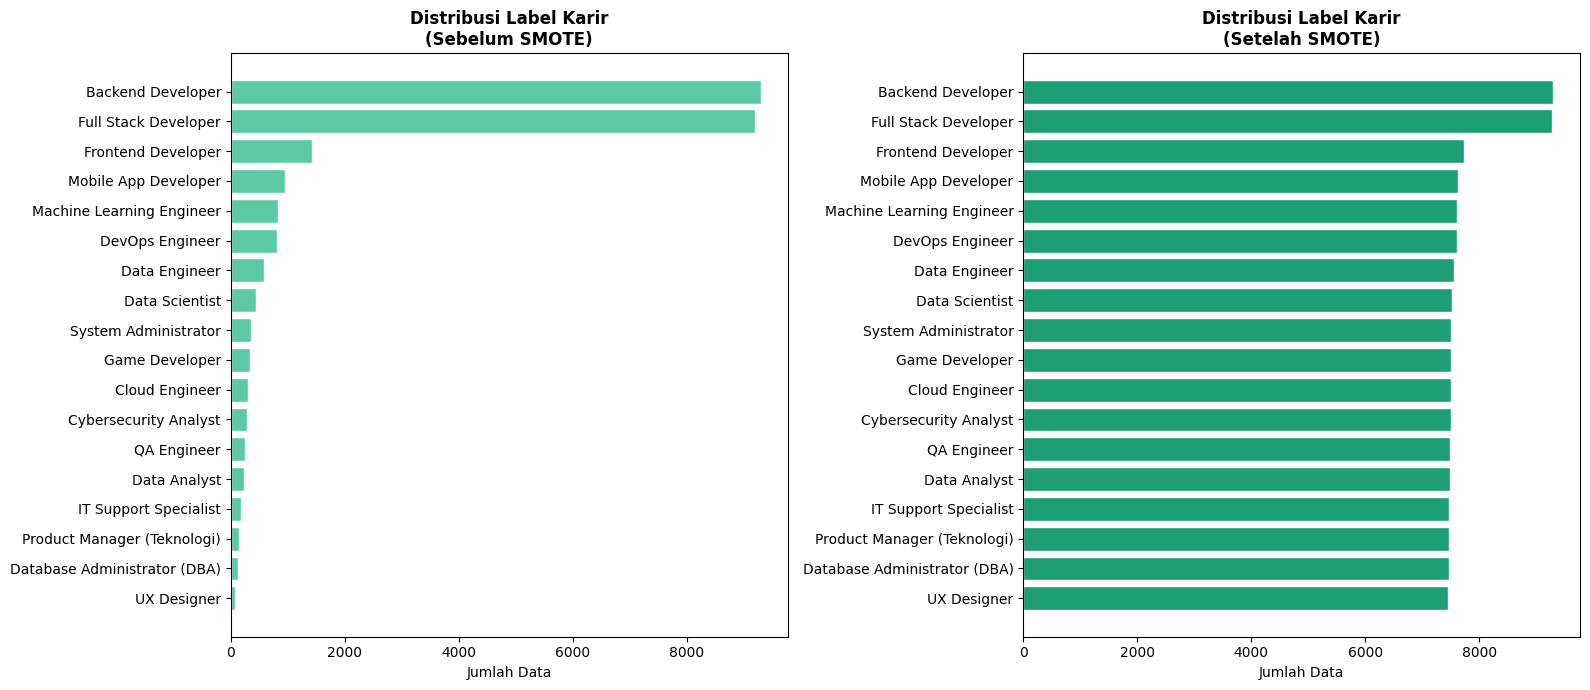

In [17]:
print("\n" + "=" * 65)
print("STEP 14 : VISUALISASI DISTRIBUSI DATASET")
print("=" * 65)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

counts_before = df_final['career_label'].value_counts()
axes[0].barh(counts_before.index, counts_before.values, color='#5DCAA5', edgecolor='white')
axes[0].set_title('Distribusi Label Karir\n(Sebelum SMOTE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Data')
axes[0].invert_yaxis()

counts_after = df_balanced['career_label'].value_counts()
axes[1].barh(counts_after.index, counts_after.values, color='#1D9E75', edgecolor='white')
axes[1].set_title('Distribusi Label Karir\n(Setelah SMOTE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Data')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## STEP 15 — Data Injection Keyword Karir

Pada tahap ini dilakukan injeksi keyword karir-spesifik ke dalam kolom `all_skills` dan `tools` untuk memperkuat sinyal fitur bagi karir-karir yang memiliki terminologi teknis khas namun mungkin kurang terwakili dalam data survei asli. Input diambil **langsung dari `df_balanced` di memori** (bukan membaca ulang file CSV), sehingga seluruh pipeline tetap mengalir tanpa file antara.

**Mekanisme injeksi:**
- Setiap baris dicek berdasarkan nilai `career_label`-nya
- Keyword yang **belum ada** di kolom ditambahkan secara acak (1–3 skill, 1–2 tools)
- Urutan item dikocok ulang agar tidak terbentuk pola posisi yang artifisial
- Separator distandarkan ke `;` (tanpa spasi) agar konsisten dengan hasil cleaning dan **siap diparse pada tahap pemodelan**

**Karir yang mendapatkan injeksi keyword:**

| Karir | Contoh Skill yang Diinjeksikan |
|---|---|
| Machine Learning Engineer | `tensorflow`, `pytorch`, `keras` |
| Data Scientist | `pandas`, `numpy`, `statistical modeling` |
| Data Analyst | `tableau`, `power bi`, `dax` |
| Data Engineer | `apache airflow`, `etl`, `dbt` |
| Cybersecurity Analyst | `penetration testing`, `wireshark`, `kali linux` |
| Mobile App Developer | `flutter`, `swift`, `kotlin` |
| Game Developer | `unity3d`, `unreal engine`, `blender` |
| QA Engineer | `selenium`, `cypress`, `automated testing` |
| UX Designer | `figma`, `wireframing`, `prototyping` |

Hasil injeksi disimpan sebagai DataFrame `df_injected`; penulisan ke file final dilakukan pada STEP 16 setelah validasi.

In [18]:
print("\n" + "=" * 65)
print("STEP 15 : DATA INJECTION KEYWORD KARIR")
print("=" * 65)

# Input langsung dari df_balanced di memori (bukan baca file CSV)
df_injected = df_balanced.copy()

# Random seed agar hasil injeksi reproducible
random.seed(42)
np.random.seed(42)

# Mapping injection: keyword khas per karir
mapping = {
    "Machine Learning Engineer": {
        "skills": [
            "tensorflow", "pytorch", "keras",
            "scikit-learn", "deep learning",
            "computer vision", "nlp",
            "neural networks"
        ],
        "tools": [
            "jupyter notebook",
            "google colab",
            "huggingface"
        ]
    },

    "Data Scientist": {
        "skills": [
            "machine learning",
            "statistical modeling",
            "pandas",
            "numpy",
            "matplotlib",
            "seaborn",
            "data mining"
        ],
        "tools": [
            "rstudio",
            "jupyterlab",
            "knime"
        ]
    },

    "Data Analyst": {
        "skills": [
            "data visualization",
            "exploratory data analysis",
            "dax",
            "business intelligence",
            "google analytics"
        ],
        "tools": [
            "tableau",
            "power bi",
            "microsoft excel",
            "looker"
        ]
    },

    "Data Engineer": {
        "skills": [
            "etl",
            "data warehousing",
            "apache airflow",
            "apache kafka",
            "hadoop",
            "dbt",
            "data pipeline"
        ],
        "tools": [
            "snowflake",
            "databricks",
            "apache spark",
            "talend"
        ]
    },

    "Cybersecurity Analyst": {
        "skills": [
            "penetration testing",
            "ethical hacking",
            "cryptography",
            "network security",
            "malware analysis",
            "vulnerability assessment"
        ],
        "tools": [
            "wireshark",
            "kali linux",
            "burp suite",
            "metasploit",
            "nmap"
        ]
    },

    "Mobile App Developer": {
        "skills": [
            "swift",
            "kotlin",
            "flutter",
            "react native",
            "dart",
            "mobile ui/ux"
        ],
        "tools": [
            "xcode",
            "android studio",
            "emulator"
        ]
    },

    "Game Developer": {
        "skills": [
            "game physics",
            "3d modeling",
            "unity3d",
            "unreal engine",
            "gameplay programming"
        ],
        "tools": [
            "unity editor",
            "unreal editor",
            "blender",
            "godot"
        ]
    },

    "QA Engineer": {
        "skills": [
            "automated testing",
            "selenium",
            "cypress",
            "test-driven development (tdd)",
            "api testing",
            "performance testing"
        ],
        "tools": [
            "postman",
            "jira",
            "selenium webdriver",
            "appium",
            "katalon"
        ]
    },

    "UX Designer": {
        "skills": [
            "wireframing",
            "prototyping",
            "user research",
            "ui design",
            "interaction design",
            "usability testing"
        ],
        "tools": [
            "figma",
            "adobe xd",
            "sketch",
            "invision",
            "miro"
        ]
    }
}

# Function injection: tambahkan keyword yang belum ada, join dengan ';'
# (konsisten dengan separator hasil cleaning, siap diparse saat modeling)
def inject_keywords(existing_text, additions, max_add=3):

    if pd.isna(existing_text):
        existing_items = []
    else:
        existing_items = [
            x.strip().lower()
            for x in str(existing_text).split(";")
            if x.strip()
        ]

    available = [
        x for x in additions
        if x.lower() not in existing_items
    ]

    if not available:
        return ";".join(dict.fromkeys(existing_items))

    selected = random.sample(
        available,
        random.randint(1, min(max_add, len(available)))
    )

    combined = existing_items + selected
    random.shuffle(combined)

    return ";".join(dict.fromkeys(combined))

# Process injection
for idx, row in df_injected.iterrows():

    label = row["career_label"]

    if label in mapping:

        df_injected.at[idx, "all_skills"] = inject_keywords(
            row["all_skills"],
            mapping[label]["skills"],
            max_add=3
        )

        df_injected.at[idx, "tools"] = inject_keywords(
            row["tools"],
            mapping[label]["tools"],
            max_add=2
        )

print(f"\n  ✅ Injeksi selesai pada {len(mapping)} karir target")
print(f"     Shape df_injected : {df_injected.shape}")


STEP 15 : DATA INJECTION KEYWORD KARIR



  ✅ Injeksi selesai pada 9 karir target
     Shape df_injected : (139079, 6)


## STEP 16 — Validasi Akhir & Simpan Satu File Final

Tahap terakhir memastikan dataset benar-benar **siap digunakan pada tahap pemodelan** sebelum ditulis ke satu-satunya file output, `dataset_so_smote_balanced_injected.csv`.

**Penanganan sel kosong pada `tools` & `databases`:** sebagian responden tidak menyebutkan IDE/tools (`tools` kosong) atau tidak memakai database (`databases` kosong). Ini **nilai yang sah, bukan data hilang**. Namun jika dibiarkan sebagai string kosong, `pandas` akan membacanya kembali sebagai `NaN` saat file di-load. Agar EDA lolos pengecekan *missing value* tanpa membuang baris (yang akan merusak keseimbangan SMOTE), sel kosong tersebut diisi token eksplisit **`none`**.

Validasi yang dilakukan:

1. **Tidak ada missing value** pada seluruh kolom (`NaN` = 0 saat di-load ulang).
2. **Tidak ada sel teks kosong** — kosong sudah diganti `none`.
3. **Tipe data benar** — `years_code` & `education_level` numerik; kolom skill bertipe teks dengan separator `;` yang konsisten.
4. **Setiap baris punya minimal satu skill** pada `all_skills`.
5. **Distribusi label** divisualisasikan ulang sebagai bukti pendukung kesimpulan bahwa dataset final tetap seimbang.

Kesimpulan di bawah didukung langsung oleh visualisasi distribusi label final, sehingga tidak ada klaim tanpa bukti grafik.


STEP 16 : VALIDASI AKHIR & SIMPAN SATU FILE FINAL



  [16.0] Sel kosong diisi token 'none':
         tools     : 16,635 sel
         databases : 35,263 sel

  [16.1] Shape final            : (139079, 6)
  [16.2] Total missing value    : 0
  [16.3] Baris tanpa all_skills : 0
  [16.4] Sel teks kosong tersisa: 0
  [16.5] Jumlah label karir     : 18
  [16.6] Tipe data:
         all_skills        : object
         tools             : object
         databases         : object
         years_code        : float64
         education_level   : float64
         career_label      : object

  ✅ Validasi lolos: 0 missing value & 0 sel kosong, dataset SIAP untuk pemodelan.


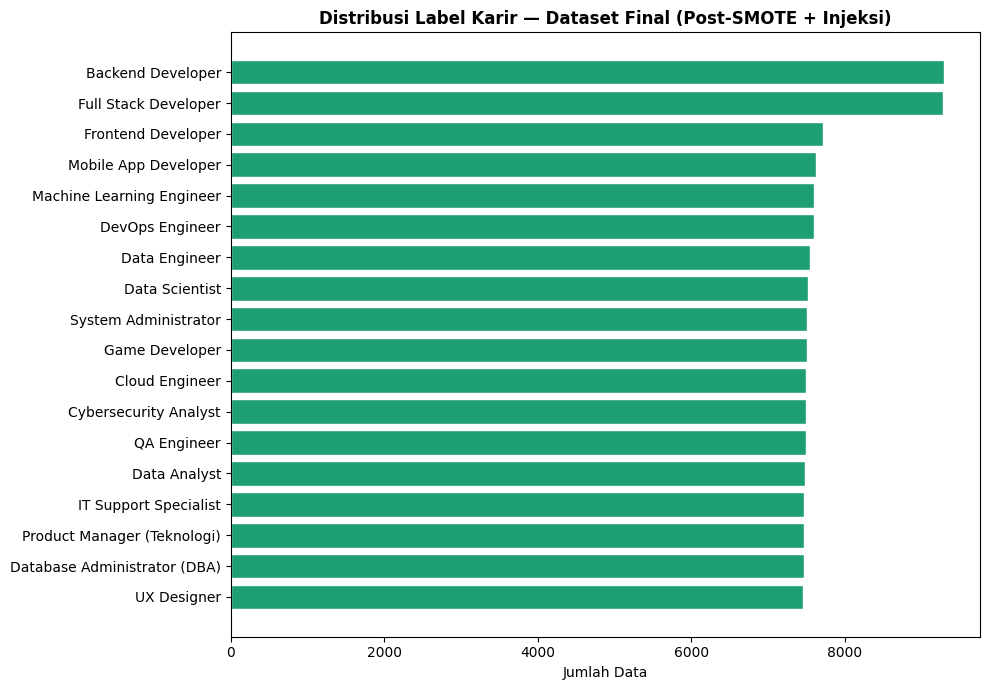


  ✅ DATASET AKHIR TERSIMPAN (hanya 1 file)
     File   : dataset_so_smote_balanced_injected.csv
     Shape  : (139079, 6)
     Size   : 30788.1 KB

  KESIMPULAN:
   - Dataset final berisi 139,079 baris × 6 kolom.
   - Mayoritas label seimbang pada 9,300 sampel (hasil SMOTE);
     rasio imbalance hanya 1.2x (selisih dari testing set asli).
   - Sel tools/databases kosong diisi 'none' tanpa membuang baris,
     sehingga 0 missing value & keseimbangan SMOTE tetap terjaga → siap untuk pemodelan.


In [19]:
print("\n" + "=" * 65)
print("STEP 16 : VALIDASI AKHIR & SIMPAN SATU FILE FINAL")
print("=" * 65)

TEXT_COLS = ['all_skills', 'tools', 'databases']
NUM_COLS  = ['years_code', 'education_level']

# Normalisasi kolom teks (string & rapikan spasi) dan numerik
for col in TEXT_COLS:
    df_injected[col] = df_injected[col].fillna('').astype(str).str.strip()
for col in NUM_COLS:
    df_injected[col] = pd.to_numeric(df_injected[col], errors='coerce')

# --- Tangani sel kosong pada tools/databases ---
# Kosong = responden tidak menyebut tools/database (nilai sah, BUKAN data hilang).
# Diisi token 'none' agar tidak terbaca NaN saat di-load ulang, TANPA membuang baris,
# sehingga keseimbangan hasil SMOTE tetap terjaga.
PLACEHOLDER = 'none'
empty_tools = int((df_injected['tools'] == '').sum())
empty_db    = int((df_injected['databases'] == '').sum())
df_injected['tools']     = df_injected['tools'].replace('', PLACEHOLDER)
df_injected['databases'] = df_injected['databases'].replace('', PLACEHOLDER)

print(f"\n  [16.0] Sel kosong diisi token '{PLACEHOLDER}':")
print(f"         tools     : {empty_tools:,} sel")
print(f"         databases : {empty_db:,} sel")

# --- Validasi kesiapan untuk pemodelan ---
n_missing      = int(df_injected.isna().sum().sum())
n_empty_skills = int((df_injected['all_skills'].str.strip() == '').sum())
n_empty_any    = int((df_injected[TEXT_COLS] == '').sum().sum())

print(f"\n  [16.1] Shape final            : {df_injected.shape}")
print(f"  [16.2] Total missing value    : {n_missing}")
print(f"  [16.3] Baris tanpa all_skills : {n_empty_skills}")
print(f"  [16.4] Sel teks kosong tersisa: {n_empty_any}")
print(f"  [16.5] Jumlah label karir     : {df_injected['career_label'].nunique()}")
print(f"  [16.6] Tipe data:")
for col in df_injected.columns:
    print(f"         {col:<18}: {df_injected[col].dtype}")

assert n_missing == 0,      "Masih ada missing value — dataset belum siap modeling!"
assert n_empty_skills == 0, "Masih ada baris tanpa skill — dataset belum siap modeling!"
assert n_empty_any == 0,    "Masih ada sel teks kosong — dataset belum siap modeling!"
print("\n  ✅ Validasi lolos: 0 missing value & 0 sel kosong, dataset SIAP untuk pemodelan.")

# --- Visualisasi distribusi label final (pendukung kesimpulan) ---
counts_final = df_injected['career_label'].value_counts()

plt.figure(figsize=(10, 7))
plt.barh(counts_final.index, counts_final.values, color='#1D9E75', edgecolor='white')
plt.title('Distribusi Label Karir — Dataset Final (Post-SMOTE + Injeksi)',
          fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Data')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Simpan SATU file final ---
df_injected.to_csv(PATH_FINAL, index=False, encoding='utf-8')

print("\n" + "=" * 65)
print("  ✅ DATASET AKHIR TERSIMPAN (hanya 1 file)")
print("=" * 65)
print(f"     File   : {PATH_FINAL}")
print(f"     Shape  : {df_injected.shape}")
print(f"     Size   : {os.path.getsize(PATH_FINAL) / 1024:.1f} KB")

# --- Kesimpulan (didukung visualisasi di atas) ---
print("\n  KESIMPULAN:")
print(f"   - Dataset final berisi {len(df_injected):,} baris × {df_injected.shape[1]} kolom.")
print(f"   - Mayoritas label seimbang pada {counts_final.max():,} sampel (hasil SMOTE);")
print(f"     rasio imbalance hanya {counts_final.max()/counts_final.min():.1f}x (selisih dari testing set asli).")
print(f"   - Sel tools/databases kosong diisi '{PLACEHOLDER}' tanpa membuang baris,")
print(f"     sehingga 0 missing value & keseimbangan SMOTE tetap terjaga → siap untuk pemodelan.")